In [2]:
!pip install ultralytics

In [3]:
import os, random, shutil, yaml
from tqdm import tqdm
import cv2
import torch
import torchvision
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from transformers import AutoProcessor, AutoModelForZeroShotObjectDetection
from ultralytics import YOLO
from PIL import Image

device = "cuda" if torch.cuda.is_available() else "cpu"

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


# Part 1

## Data split

In [4]:
images_dir = "/kaggle/input/datasets/sinatb/dl4cv-hw4-q5-1/Dataset_Task_1/train/images"
labels_dir = "/kaggle/input/datasets/sinatb/dl4cv-hw4-q5-1/Dataset_Task_1/train/labels"

train_img_dir = "dataset/train/images"
train_lbl_dir = "dataset/train/labels"

val_img_dir = "dataset/val/images"
val_lbl_dir = "dataset/val/labels"

os.makedirs(train_img_dir, exist_ok=True)
os.makedirs(train_lbl_dir, exist_ok=True)
os.makedirs(val_img_dir, exist_ok=True)
os.makedirs(val_lbl_dir, exist_ok=True)

all_images = [x for x in os.listdir(images_dir) if x.endswith(".jpg")]
random.shuffle(all_images)

split_idx = int(0.8 * len(all_images))
train_images = all_images[:split_idx]
val_images = all_images[split_idx:]

def copy_files(image_list, dst_img, dst_lbl):
    for img_name in tqdm(image_list):
        label_name = img_name.replace(".jpg", ".txt")
        
        shutil.copy(
            os.path.join(images_dir, img_name),
            os.path.join(dst_img, img_name)
        )
        
        label_path = os.path.join(labels_dir, label_name)
        with open(label_path, 'r') as f:
            lines = f.readlines()
        
        filtered = []
        for line in lines:
            parts = line.strip().split()
            if len(parts) == 5 and int(parts[0]) == 1:
                parts[0] = str(0)   
                filtered.append(" ".join(parts) + "\n")
        
        out_label_path = os.path.join(dst_lbl, label_name)
        with open(out_label_path, 'w') as f:
            f.writelines(filtered)

copy_files(train_images, train_img_dir, train_lbl_dir)   
copy_files(val_images, val_img_dir, val_lbl_dir)

print("Dataset split completed.")

100%|██████████| 984/984 [00:17<00:00, 56.75it/s]

Dataset split completed.


## Training YOLO

In [5]:
data = {
    'path': 'dataset',
    'train': 'train/images',
    'val': 'val/images',
    'names': {
        0: 'saftey hat',
    }
}

with open('hardhat.yaml', 'w') as file:
    yaml.dump(data, file, default_flow_style=False, sort_keys=False)

In [6]:
yolo_model = YOLO("yolov8n.pt")

yolo_model.train(
    data="hardhat.yaml",
    epochs=20,
    imgsz=640,
    batch=16,
    device=device
)

Ultralytics 8.4.56 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=hardhat.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, pl

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x78bab18ca630>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

In [7]:
yolo_model = YOLO("/kaggle/working/runs/detect/train/weights/best.pt")

test_images = [
    "/kaggle/input/datasets/sinatb/dl4cv-hw4-q5-test/test_crowd.png",
    "/kaggle/input/datasets/sinatb/dl4cv-hw4-q5-test/test_normal.png",
    "/kaggle/input/datasets/sinatb/dl4cv-hw4-q5-test/test_pink_helmet.png"
]
os.makedirs("outputs", exist_ok=True)
for path in test_images:
    results = yolo_model(path)
    annotated = results[0].plot()
    output_name = path.split("/")[-1]
    cv2.imwrite(f"outputs/yolo_{output_name}", annotated)

print("YOLO inference completed.")


image 1/1 /kaggle/input/datasets/sinatb/dl4cv-hw4-q5-test/test_crowd.png: 352x640 27 saftey hats, 44.6ms
Speed: 1.8ms preprocess, 44.6ms inference, 1.3ms postprocess per image at shape (1, 3, 352, 640)

image 1/1 /kaggle/input/datasets/sinatb/dl4cv-hw4-q5-test/test_normal.png: 384x640 2 saftey hats, 43.2ms
Speed: 1.9ms preprocess, 43.2ms inference, 1.5ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 /kaggle/input/datasets/sinatb/dl4cv-hw4-q5-test/test_pink_helmet.png: 448x640 1 saftey hat, 42.1ms
Speed: 2.3ms preprocess, 42.1ms inference, 1.7ms postprocess per image at shape (1, 3, 448, 640)
YOLO inference completed.


## Grounding DiNO

In [8]:
grounding_dino_processor = AutoProcessor.from_pretrained(
    "IDEA-Research/grounding-dino-base"
)
grounding_dino_model = AutoModelForZeroShotObjectDetection.from_pretrained(
    "IDEA-Research/grounding-dino-base"
)
grounding_dino_model.to(device)

preprocessor_config.json:   0%|          | 0.00/457 [00:00<?, ?B/s]

The image processor of type `GroundingDinoImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/933M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/1206 [00:00<?, ?it/s]

GroundingDinoForObjectDetection(
  (model): GroundingDinoModel(
    (backbone): GroundingDinoConvModel(
      (conv_encoder): GroundingDinoConvEncoder(
        (model): SwinBackbone(
          (embeddings): SwinEmbeddings(
            (patch_embeddings): SwinPatchEmbeddings(
              (projection): Conv2d(3, 128, kernel_size=(4, 4), stride=(4, 4))
            )
            (norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
            (dropout): Dropout(p=0.0, inplace=False)
          )
          (encoder): SwinEncoder(
            (layers): ModuleList(
              (0): SwinStage(
                (blocks): ModuleList(
                  (0): SwinLayer(
                    (layernorm_before): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
                    (attention): SwinAttention(
                      (self): SwinSelfAttention(
                        (query): Linear(in_features=128, out_features=128, bias=True)
                        (key): Linear(in_featu

/usr/local/lib/python3.12/dist-packages/transformers/models/grounding_dino/processing_grounding_dino.py:91: FutureWarning: The key `labels` is will return integer ids in `GroundingDinoProcessor.post_process_grounded_object_detection` output since v4.51.0. Use `text_labels` instead to retrieve string object names.
  warnings.warn(self.message, FutureWarning)


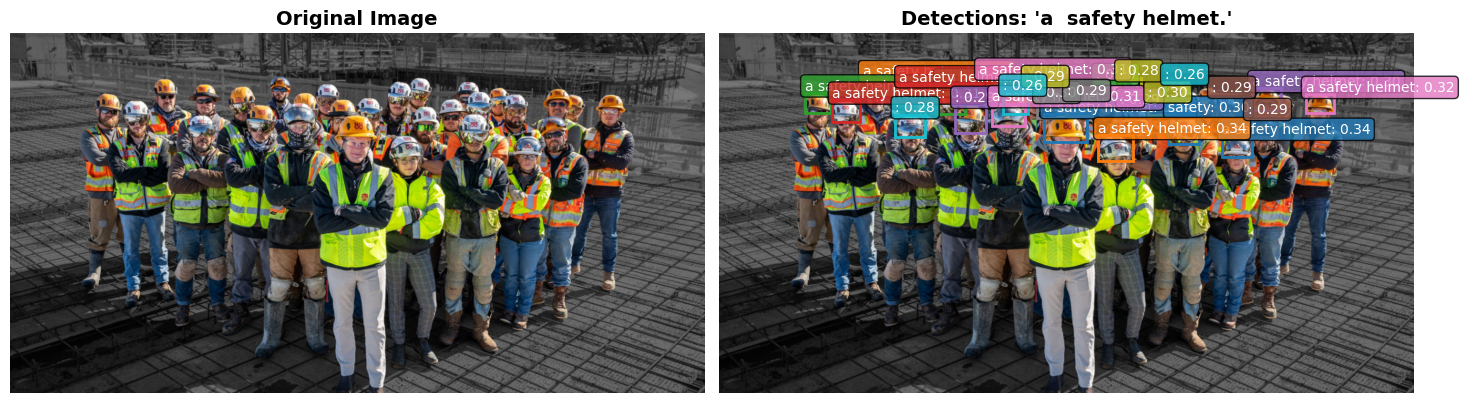

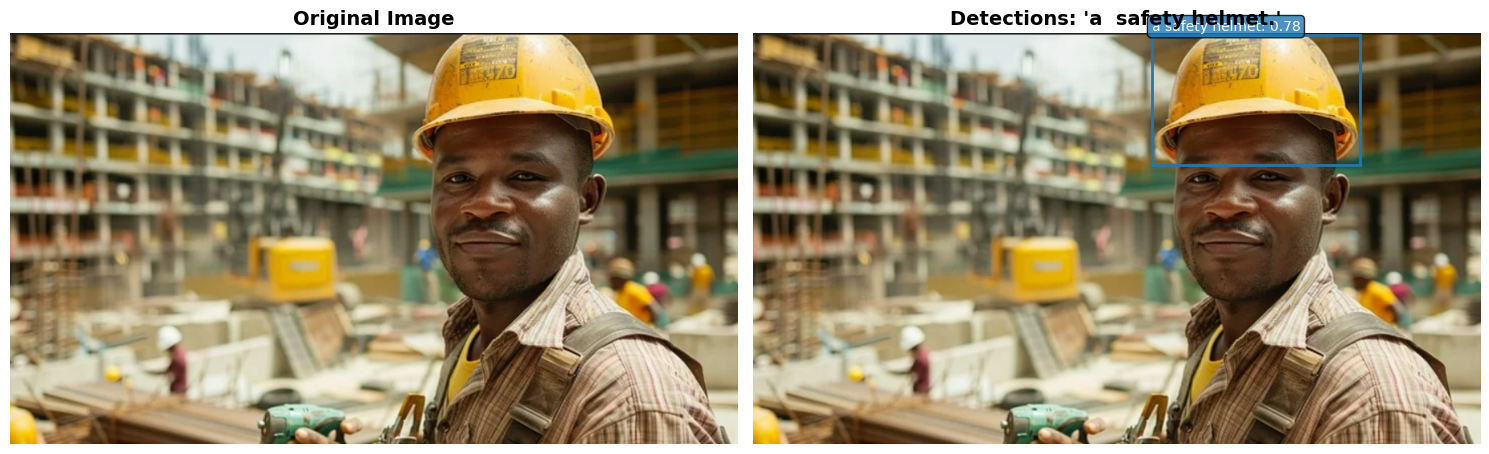

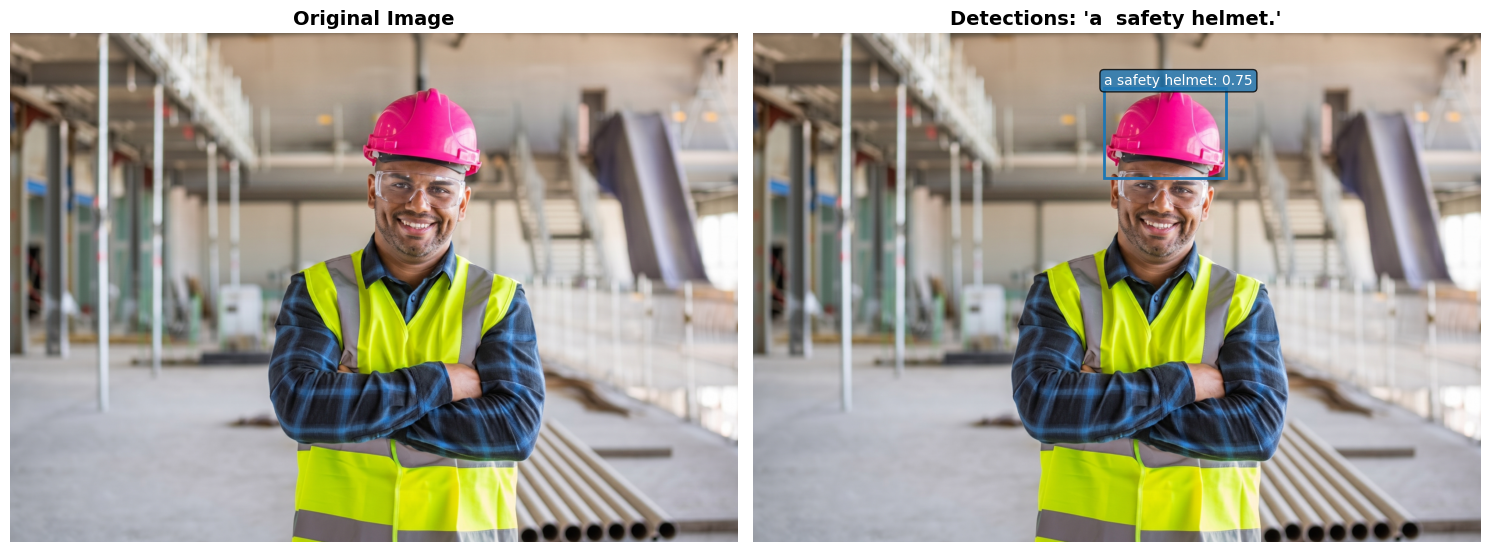

In [9]:
prompt = "a  safety helmet."
for path in test_images:
    image = Image.open(path).convert('RGB') 
    inputs = grounding_dino_processor(images=image,
                                      text=prompt,
                                      return_tensors="pt").to(device)
    with torch.no_grad():
        outputs = grounding_dino_model(**inputs)
    
    results = grounding_dino_processor.post_process_grounded_object_detection(
        outputs,
        inputs.input_ids,
        text_threshold=0.3,
        target_sizes=[image.size[::-1]]
    )
    fig, axes = plt.subplots(1, 2, figsize=(15, 7))
    
    axes[0].imshow(image)
    axes[0].set_title("Original Image", fontsize=14, fontweight='bold')
    axes[0].axis('off')
    
    axes[1].imshow(image)
    axes[1].set_title(f"Detections: '{prompt}'", fontsize=14, fontweight='bold')
    
    colors = plt.cm.tab10(np.linspace(0, 1, len(results[0]['boxes'])))
    
    for i, (box, score, label) in enumerate(zip(results[0]['boxes'], 
                                               results[0]['scores'], 
                                               results[0]['labels'])):
        x1, y1, x2, y2 = box.tolist() if torch.is_tensor(box) else box
        
        rect = patches.Rectangle(
            (x1, y1), x2 - x1, y2 - y1,
            linewidth=2, edgecolor=colors[i], facecolor='none'
        )
        axes[1].add_patch(rect)
        
        label_text = f"{label}: {score:.2f}"
        axes[1].text(
            x1, y1 - 5, label_text,
            fontsize=10, color='white',
            bbox=dict(boxstyle="round,pad=0.3", facecolor=colors[i], alpha=0.8)
        )
    
    axes[1].axis('off')
    plt.tight_layout()
    plt.show()

## SSD

In [10]:
ssd_model = torchvision.models.detection.ssd300_vgg16(pretrained=True)
ssd_model.eval()

anchors_output = {}

def hook_fn(module, input, output):
    anchors_output["anchors"] = output

hook = ssd_model.anchor_generator.register_forward_hook(hook_fn)

image = Image.open(test_images[1]).convert('RGB')
orig_w, orig_h = image.size 

transform = torchvision.transforms.Compose([
    torchvision.transforms.Resize((300, 300)),   
    torchvision.transforms.ToTensor()            
])
tensor_image  = transform(image)

with torch.no_grad():
    predictions = ssd_model([tensor_image])

hook.remove()

anchors_list = anchors_output["anchors"]  
anchors = torch.cat(anchors_list, dim=0)  

scale_x = orig_w / 300
scale_y = orig_h / 300
anchors[:, [0, 2]] *= scale_x
anchors[:, [1, 3]] *= scale_y

print("Number of anchor boxes:", anchors.shape[0])

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=SSD300_VGG16_Weights.COCO_V1`. You can also use `weights=SSD300_VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/ssd300_vgg16_coco-b556d3b4.pth" to /root/.cache/torch/hub/checkpoints/ssd300_vgg16_coco-b556d3b4.pth


100%|██████████| 136M/136M [00:03<00:00, 43.2MB/s] 


Number of anchor boxes: 8732


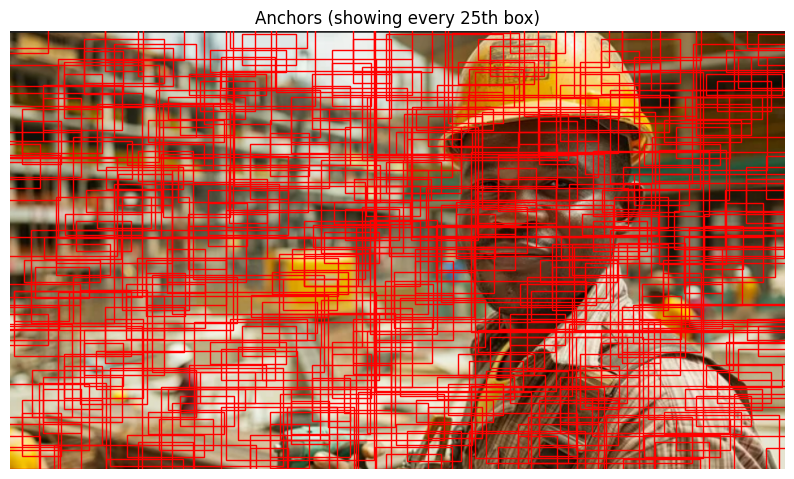

In [11]:
orig_image = Image.open(test_images[1]).convert('RGB')

fig, ax = plt.subplots(1, figsize=(10, 10))
ax.imshow(orig_image)

for i in range(0, anchors.shape[0], 25):
    x1, y1, x2, y2 = anchors[i].tolist()
    rect = patches.Rectangle(
        (x1, y1), x2 - x1, y2 - y1,
        linewidth=1, edgecolor='red', facecolor='none'
    )
    ax.add_patch(rect)

plt.title(f"Anchors (showing every 25th box)")
plt.axis('off')
plt.show()

## Evaluation

In [12]:
def compute_iou(box1, box2):
    inter_x1 = max(box1[0], box2[0])
    inter_y1 = max(box1[1], box2[1])
    inter_x2 = min(box1[2], box2[2])
    inter_y2 = min(box1[3], box2[3])
    if inter_x2 < inter_x1 or inter_y2 < inter_y1:
        return 0.0
    inter_area = (inter_x2 - inter_x1) * (inter_y2 - inter_y1)
    area1 = (box1[2] - box1[0]) * (box1[3] - box1[1])
    area2 = (box2[2] - box2[0]) * (box2[3] - box2[1])
    return inter_area / (area1 + area2 - inter_area)

In [13]:
val_img_dir = "dataset/val/images"
val_label_dir = "dataset/val/labels"
gt_boxes_all = []
for label_file in os.listdir(val_label_dir):
    with open(os.path.join(val_label_dir, label_file), 'r') as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) == 5:
                class_id, xc, yc, w, h = map(float, parts)
                gt_boxes_all.append(1) 
num_gt_total = len(gt_boxes_all)
print(num_gt_total)

2710


In [14]:
def evaluate_grounding_dino(model, processor):
    all_preds = []
    val_img_dir = "dataset/val/images"
    val_label_dir = "dataset/val/labels"
    
    image_files = [f for f in os.listdir(val_img_dir) if f.endswith('.jpg')]
    prompt = "a safety helmet."
    
    for img_name in image_files:
        img_path = os.path.join(val_img_dir, img_name)
        label_path = os.path.join(val_label_dir, img_name.replace('.jpg', '.txt'))
        
        gt_boxes = []
        with open(label_path, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) == 5:
                    class_id, xc, yc, w, h = map(float, parts)
                    img = cv2.imread(img_path)
                    h_img, w_img = img.shape[:2]
                    x1 = (xc - w/2) * w_img
                    y1 = (yc - h/2) * h_img
                    x2 = (xc + w/2) * w_img
                    y2 = (yc + h/2) * h_img
                    gt_boxes.append([x1, y1, x2, y2])
        
        image = Image.open(img_path).convert('RGB')
        inputs = processor(images=image,
                           text=prompt,
                           return_tensors="pt").to(device)
        
        with torch.no_grad():
            outputs = model(**inputs)
        results = processor.post_process_grounded_object_detection(outputs,
                                                                   inputs.input_ids,
                                                                   text_threshold=0.3,
                                                                   target_sizes=[image.size[::-1]])
        pred_boxes = results[0]['boxes'].cpu().numpy()
        pred_scores = results[0]['scores'].cpu().numpy()
        
        matched_gt = set()
        for i, (pred, score) in enumerate(zip(pred_boxes, pred_scores)):
            best_iou = 0
            best_gt_idx = -1
            for j, gt in enumerate(gt_boxes):
                if j in matched_gt:
                    continue
                iou = compute_iou(pred, gt)
                if iou > best_iou:
                    best_iou = iou
                    best_gt_idx = j
            if best_iou >= 0.5:
                all_preds.append((score, best_iou, 1))
                matched_gt.add(best_gt_idx)
            else:
                all_preds.append((score, best_iou, 0))
    
    all_preds.sort(key=lambda x: -x[0])
    tp_cum = 0
    fp_cum = 0
    precisions = []
    recalls = []
    for i, (_, _, is_tp) in enumerate(all_preds):
        if is_tp:
            tp_cum += 1
        else:
            fp_cum += 1
        prec = tp_cum / (tp_cum + fp_cum) if (tp_cum+fp_cum)>0 else 0
        rec = tp_cum / num_gt_total if num_gt_total>0 else 0
        precisions.append(prec)
        recalls.append(rec)
    
    ap = 0
    for r in np.linspace(0, 1, 101):
        prec_at_r = max([p for p, rec in zip(precisions, recalls) if rec >= r], default=0)
        ap += prec_at_r / 101
    mean_iou = np.mean([iou for (_, iou, _) in all_preds if iou>0]) if all_preds else 0
    return ap, precisions[-1] if precisions else 0, recalls[-1] if recalls else 0, mean_iou


In [15]:
dino_ap, dino_prec, dino_rec, dino_miou = evaluate_grounding_dino(
    grounding_dino_model,
    grounding_dino_processor
)
print(25*"=" + " Grounding DiNO Results" + 25*"=")
print(f"mAP: {dino_ap:.4f}")    
print(f"Precision: {dino_prec:.4f}")    
print(f"Recall:    {dino_rec:.4f}") 
print(f"mean IoU {dino_miou:.4f}")

========================= Grounding DiNO Results=========================
mAP: 0.3271
Precision: 0.5689
Recall:    0.4893
mean IoU 0.5441


In [16]:
metrics = yolo_model.val()  
print(25*"=" + " Yolo Results" + 25*"=")
print(f"mAP50-95: {metrics.box.map:.4f}")    
print(f"mAP50:     {metrics.box.map50:.4f}") 
print(f"mAP75:     {metrics.box.map75:.4f}") 
print(f"Precision: {metrics.box.mp:.4f}")    
print(f"Recall:    {metrics.box.mr:.4f}") 

Ultralytics 8.4.56 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1229.6±355.9 MB/s, size: 35.0 KB)
val: Scanning /kaggle/working/dataset/val/labels.cache... 984 images, 86 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 984/984 343.9Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 62/62 8.1it/s 7.7s0.2ss
                   all        984       2710      0.954      0.932      0.979      0.668
Speed: 0.7ms preprocess, 3.2ms inference, 0.0ms loss, 0.8ms postprocess per image
Results saved to /kaggle/working/runs/detect/val
========================= Yolo Results=========================
mAP50-95: 0.6681
mAP50:     0.9786
mAP75:     0.8028
Precision: 0.9543
Recall:    0.9324


In [17]:
import time
def measure_fps(model, processor, image_paths, prompt="a safety helmet.", repeats=5):
    times = []
    for path in image_paths:
        image = Image.open(path).convert('RGB')
        inputs = processor(images=image,
                           text=prompt,
                           return_tensors="pt").to(device)
        
        for _ in range(3):
            with torch.no_grad():
                _ = model(**inputs)
        
        torch.cuda.synchronize() if device=='cuda' else None
        start = time.time()
        for _ in range(repeats):
            with torch.no_grad():
                _ = model(**inputs)
        torch.cuda.synchronize() if device=='cuda' else None
        end = time.time()
        times.append((end-start)/repeats)
    fps = 1.0 / np.mean(times)
    return fps

fps = measure_fps(grounding_dino_model, grounding_dino_processor, test_images)
print(f"Grounding DINO FPS: {fps:.2f} frames per second")

Grounding DINO FPS: 1.31 frames per second


In [18]:
shutil.copy("/kaggle/working/runs/detect/train/weights/best.pt",
            "yolo_helmet_part1.pt")

'yolo_helmet_part1.pt'

## Analysis

First of all let me talk about the dataset. I think the dataset and the things that are actually wanted by the homework do not align. To my knowledge and by looking at the images and labels of dozens of examples, There are 3 classes in this dataset : 

0. Head with no helmet
1. Head with safety helmet
2. Person

The prompt used for finding the objects using grounding Dino is "a saftey helmet" which does not completely match with the annotated data. This will result in a decreased amount of IoU/percision/recall for the grounding Dino method. I think it would have been better if we used "a head with saftey helmet." as the prompt.

Now for the questions, first of all the YoLo model perfectly finds heads with saftey helmet in all the 3 examples. The thing is there are many different kinds of hats in the dataset. Some blue, some purple and others white. So in essence there is no sort of overfitting to the hat color in YoLo. The model has seen all the different kinds of hats during training. 

Grounding Dino has a good performance on finding the saftey helmets, Although the confidence score is very low compared to YoLo.

In the crowded scene I think Grounding Dino outperforms YoLo. I think the reason for this is the fact that Grounding Dino does not require NMS. Now NMS might remove some true positives in a grounded scene resulting in a reduced recall.

There are a lot of anchor boxes created when using SSD. If I drew all of them the image would have been completely red, So I drew every 25th anchor. The anchors are a lot and this is because of the multiscale strategy used in SSD, where predictions are done on feature maps with different sizes and resolutions. This is done so the model does not miss any ground truth objects.

Now with respect to realtime performance, YoLo takes 3.2 ms for inference this means almost 300 fps while grounding Dino only achieves 1 fps. There is a clear advantage to YoLo in this field.

# Part 2

In [20]:
unlabeled_img_dir = "/kaggle/input/datasets/sinatb/dl4cv-hw4-q5-task-2/Dataset_Task_2/valid/images" 
pseudo_label_dir = "pseudo/train/labels"
pseudo_images_dir = "pseudo/train/images"
pseudo_val_label_dir = "pseudo/val/labels"
pseudo_val_images_dir = "pseudo/val/images"

os.makedirs(pseudo_label_dir, exist_ok=True)
os.makedirs(pseudo_images_dir, exist_ok=True)
os.makedirs(pseudo_val_label_dir, exist_ok=True)
os.makedirs(pseudo_val_images_dir, exist_ok=True)

prompt = "a safety helmet."
## I changed this to 40 because with 85 no training will happen.
confidence_threshold = 0.40

all_pseudo_images = [x for x in os.listdir(unlabeled_img_dir) if x.endswith(".jpg")]
random.shuffle(all_pseudo_images) 
split_idx = int(0.9 * len(all_pseudo_images))
pseudo_train_images = all_pseudo_images[:split_idx]
pseudo_val_images = all_pseudo_images[split_idx:]

def copy_pseudo_files(image_list, dst_img, dst_lbl):
    for img_name in tqdm(image_list):
        img_path = os.path.join(unlabeled_img_dir, img_name)
        image = Image.open(img_path).convert('RGB')
        w_img, h_img = image.size

        inputs = grounding_dino_processor(images=image,
                                          text=prompt,
                                          return_tensors="pt").to(device)
        with torch.no_grad():
            outputs = grounding_dino_model(**inputs)
            results = grounding_dino_processor.post_process_grounded_object_detection(
                outputs,
                inputs.input_ids,
                text_threshold=0.0,
                target_sizes=[(h_img, w_img)]
            )
        shutil.copy(
            os.path.join(unlabeled_img_dir, img_name),
            os.path.join(dst_img, img_name)
        )

        label_file = os.path.join(dst_lbl, img_name.replace('.jpg', '.txt'))
        with open(label_file, 'w') as f:
            for box, score in zip(results[0]['boxes'], results[0]['scores']):
                if score < confidence_threshold:
                    continue
                x1, y1, x2, y2 = box.tolist()
                xc = (x1 + x2) / 2 / w_img
                yc = (y1 + y2) / 2 / h_img
                w = (x2 - x1) / w_img
                h = (y2 - y1) / h_img
                f.write(f"0 {xc:.6f} {yc:.6f} {w:.6f} {h:.6f}\n") 
    
copy_pseudo_files(pseudo_train_images,pseudo_images_dir,pseudo_label_dir)
copy_pseudo_files(pseudo_val_images,pseudo_val_images_dir,pseudo_val_label_dir)
    
print("Pseudo-labeling completed.")

100%|██████████| 142/142 [01:52<00:00,  1.26it/s]

Pseudo-labeling completed.


In [21]:
data_pseudo = {
    'path': 'pseudo',
    'train': 'train/images',
    'val': 'val/images',
    'names': {
        0: 'saftey hat',
    }
}

with open('pseudo_hardhat.yaml', 'w') as file:
    yaml.dump(data_pseudo, file, default_flow_style=False, sort_keys=False)

In [22]:
yolo_resumed = YOLO("yolo_helmet_part1.pt")

yolo_resumed.train(data='pseudo_hardhat.yaml',
                  epochs=10,
                  imgsz=640,
                  batch=16,
                  device=device,
                  resume=False)

Ultralytics 8.4.56 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=pseudo_hardhat.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo_helmet_part1.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, 

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x78bab74a4ef0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

In [23]:
for path in test_images:
    results = yolo_resumed(path)
    annotated = results[0].plot()
    output_name = path.split("/")[-1]
    cv2.imwrite(f"outputs/yolo_resumed_{output_name}", annotated)

print("YOLO resumed inference completed.")


image 1/1 /kaggle/input/datasets/sinatb/dl4cv-hw4-q5-test/test_crowd.png: 352x640 (no detections), 7.5ms
Speed: 2.0ms preprocess, 7.5ms inference, 0.7ms postprocess per image at shape (1, 3, 352, 640)

image 1/1 /kaggle/input/datasets/sinatb/dl4cv-hw4-q5-test/test_normal.png: 384x640 1 saftey hat, 7.4ms
Speed: 3.4ms preprocess, 7.4ms inference, 1.3ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 /kaggle/input/datasets/sinatb/dl4cv-hw4-q5-test/test_pink_helmet.png: 448x640 1 saftey hat, 7.3ms
Speed: 2.4ms preprocess, 7.3ms inference, 1.3ms postprocess per image at shape (1, 3, 448, 640)
YOLO resumed inference completed.


## Analysis

First of all setting the confidence 0.85 did not work. When I did that there would be no predictions in the labels folder and so the model would learn to predict nothing. So I set the confidence threshold to 0.40, with this new thresholds there are actually some ground truths for the model to learn from. The resulting images are saved at **Q5-outputs** directory. As we can see, the new model is more aligned with the grounding Dino objective which was finding saftey hats and not just heads with saftey hats. So the results are a lot more authentic and comparable. On the other hand the model has completely failed in the case of the crowded scene.

I think if I decreased the threshold to 0.3, the model could have predicted better in the crowded scene, as it would have seen more examples during training and more examples would have been labeld by Grounding Dino. But this is a tradeoff, if threshold is reduced too much, the model will be prone to noises detected as saftey hats by Grounding Dino. So I think the quality of the model is greatly dependent on the threshold hyper parameter.

## Notice
I used AI generated code for calculating the scores for Grounding Dino, the other parts are all written by myself.